<div style="display:flex; justify-content:space-between; align-items:center; width:100%; margin:8px 0 24px 0;">
  <div style="text-align:left;">
    <img src="https://www.ec-nantes.fr/medias/photo/logocn-rvb_1648479844750-png?ID_FICHE=178994&amp;INLINE=FALSE" alt="Centrale Nantes" style="height:72px; width:auto;">
  </div>
  <div style="text-align:right; font-size:18px; font-weight:600; color:#17324d; line-height:1.35;">
    MSc. CORO DASSIP
  </div>
</div>

<div style="border:2px solid #333; padding:14px 20px; margin:15px auto 25px auto; width:85%; max-width:900px; box-sizing:border-box; text-align:center;">
  <h1 style="margin:0;"><b>Background Subtraction</b></h1>
</div>

## 1. Configure the Processing Environment

In [1]:
# Configure imports, paths, frame IDs, and shared pipeline parameters.

from pathlib import Path
import warnings

# Numerical arrays and result tables.
import numpy as np
import pandas as pd

# Plot figures produced by each pipeline stage.
import matplotlib.pyplot as plt

# Image I/O, filtering, thresholding, and morphology.
import skimage.io as io
from skimage import color
from skimage.filters import gaussian, threshold_otsu
from skimage.morphology import disk, dilation, erosion, opening

# Percentile statistics and probabilistic segmentation.
from scipy import stats

from sklearn.mixture import GaussianMixture

warnings.filterwarnings("ignore")


# Keep paths repository-relative for portability.
DATA_DIR = Path("../data/catheter")
FIGURE_DIR = Path("../outputs/figures")
OUTPUT_DIR = FIGURE_DIR.parent

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Frame 201 is the reference; the remaining frames are evaluated.
FRAME_NUMBERS = list(range(201, 292, 10))

BACKGROUND_FRAME = 201
EVALUATION_FRAMES = [
    frame
    for frame in FRAME_NUMBERS
    if frame != BACKGROUND_FRAME
]


# Shared parameters: change them here to keep every experiment consistent.
GAUSSIAN_SIGMA = 1.0

PREPROCESS_LOW_PERCENTILE = 0
PREPROCESS_HIGH_PERCENTILE = 90

SPECTRAL_CUTOFF = 10.0

DILATION_RADIUS = 2

RESIDUAL_LOW_PERCENTILE = 10
RESIDUAL_HIGH_PERCENTILE = 100

FIXED_THRESHOLD = 0.10

OPENING_RADIUS = 2

GMM_COMPONENTS = 2
GMM_RANDOM_STATE = 0


# Print configuration once to catch setup errors early.
print(f"Dataset directory : {DATA_DIR.resolve()}")
print(f"Figures directory : {FIGURE_DIR.resolve()}")
print(f"Frames            : {FRAME_NUMBERS}")
print(f"Evaluation frames : {EVALUATION_FRAMES}")


Dataset directory : /home/runner/work/Master_SIP_EC-Nantes/Master_SIP_EC-Nantes/Lab_Works/Image_Processing/Project/Background_Subtraction/data/catheter
Figures directory : /home/runner/work/Master_SIP_EC-Nantes/Master_SIP_EC-Nantes/Lab_Works/Image_Processing/Project/Background_Subtraction/outputs/figures
Frames            : [201, 211, 221, 231, 241, 251, 261, 271, 281, 291]
Evaluation frames : [211, 221, 231, 241, 251, 261, 271, 281, 291]


## 2. Define Reusable Processing and Evaluation Functions

In [2]:
# Define reusable functions for preprocessing, segmentation, metrics, and overlays.

def saturate(image, lower_percentile, upper_percentile):
    """Percentile-based linear contrast normalization to [0, 1]."""

    # Work in float to avoid integer clipping during normalization.
    image = np.asarray(image, dtype=np.float64)

    # Compute robust lower/upper intensity bounds.
    lower = (
        np.min(image)
        if lower_percentile == 0
        else stats.scoreatpercentile(
            image,
            lower_percentile,
        )
    )

    upper = (
        np.max(image)
        if upper_percentile == 100
        else stats.scoreatpercentile(
            image,
            upper_percentile,
        )
    )

    # Linearly map the selected intensity interval to [0, 1].
    return np.clip(
        (image - lower)
        / (upper - lower + 1e-12),
        0.0,
        1.0,
    )


def load_frame(frame_number):
    """Load one fluoroscopy frame as grayscale float data in [0, 1]."""

    # Read directly as grayscale to keep a single processing channel.
    image = io.imread(
        DATA_DIR / f"frame_{frame_number}.png",
        as_gray=True,
    )

    image = image.astype(np.float64)

    # Normalize 8-bit-style input to [0, 1] when needed.
    if image.max() > 1.0:
        image /= 255.0

    return image


def load_ground_truth(frame_number):
    """Build the union of guidewire and microcatheter annotations."""

    # Read both manual annotations for the same frame.
    guidewire = io.imread(
        DATA_DIR / f"{frame_number}_GuideWire.tiff"
    )

    microcatheter = io.imread(
        DATA_DIR / f"{frame_number}_MicroCath.tiff"
    )

    # Some TIFF readers return an extra channel axis; keep one mask plane.
    if guidewire.ndim > 2:
        guidewire = guidewire[:, :, 0]

    if microcatheter.ndim > 2:
        microcatheter = microcatheter[:, :, 0]

    # Merge guidewire and microcatheter labels into one tool mask.
    full_mask = guidewire.copy()
    full_mask[
        microcatheter < 128
    ] = 0

    # Slight erosion follows the project annotation convention.
    full_mask = erosion(
        full_mask,
        disk(2),
    )

    full_mask = full_mask.astype(np.float64)

    if full_mask.max() > 1.0:
        full_mask /= 255.0

    return full_mask


def preprocess_frame(image):
    """Spatial Gaussian filtering + first histogram transformation."""

    # Smooth small intensity fluctuations before subtraction.
    smoothed = gaussian(
        image,
        sigma=GAUSSIAN_SIGMA,
    )

    # Stretch contrast after smoothing so faint devices remain visible.
    enhanced = saturate(
        smoothed,
        PREPROCESS_LOW_PERCENTILE,
        PREPROCESS_HIGH_PERCENTILE,
    )

    return enhanced


def gaussian_high_pass(shape, cutoff):
    """Centered Gaussian high-pass transfer function."""

    # Place the transfer-function origin at the centered DC location.
    rows, cols = shape
    center_y = rows // 2
    center_x = cols // 2

    # Build a radial distance grid in frequency coordinates.
    y, x = np.ogrid[
        :rows,
        :cols,
    ]

    # Measure radial frequency distance from the centered DC component.
    distance_squared = (
        (y - center_y) ** 2
        + (x - center_x) ** 2
    )

    # Gaussian low-pass response; its complement is the high-pass filter.
    low_pass = np.exp(
        -distance_squared
        / (2.0 * cutoff ** 2)
    )

    return 1.0 - low_pass


def spectral_high_pass(image, cutoff=SPECTRAL_CUTOFF):
    """Apply Gaussian high-pass filtering in the Fourier domain."""

    # Move to the centered Fourier domain before high-pass filtering.
    spectrum = np.fft.fftshift(
        np.fft.fft2(
            image
        )
    )

    # Build the filter with the same spatial shape as the spectrum.
    transfer = gaussian_high_pass(
        image.shape,
        cutoff,
    )

    # Suppress low frequencies by pointwise spectral multiplication.
    filtered_spectrum = (
        spectrum
        * transfer
    )

    # Reconstruct the spatial response after inverse FFT.
    filtered = np.real(
        np.fft.ifft2(
            np.fft.ifftshift(
                filtered_spectrum
            )
        )
    )

    # Keep only positive tool-like responses for later thresholding.
    filtered = np.maximum(
        filtered,
        0.0,
    )

    return (
        filtered,
        spectrum,
        transfer,
    )


def build_feature_image(image, background):
    """Shared preprocessing for all segmentation strategies."""

    # Apply identical preprocessing before background subtraction.
    processed = preprocess_frame(
        image
    )

    # Negate so darker moving tools produce positive residuals.
    residual = -(
        processed
        - background
    )

    # Remove slow background variation and keep thin high-frequency structures.
    (
        spectral_response,
        spectrum,
        transfer,
    ) = spectral_high_pass(
        residual,
        cutoff=SPECTRAL_CUTOFF,
    )

    # Thicken thin responses slightly before final normalization.
    morph_response = dilation(
        spectral_response,
        disk(DILATION_RADIUS),
    )

    # Normalize the final response before applying any segmentation strategy.
    feature = saturate(
        morph_response,
        RESIDUAL_LOW_PERCENTILE,
        RESIDUAL_HIGH_PERCENTILE,
    )

    return {
        "processed": processed,
        "residual": residual,
        "spectrum": spectrum,
        "transfer": transfer,
        "spectral_response": spectral_response,
        "feature": feature,
    }


def segment_fixed_threshold(feature):
    """Strategy A — deterministic threshold."""

    # Use one fixed operating point for every frame.
    return feature > FIXED_THRESHOLD


def segment_otsu(feature):
    """Strategy B — Otsu threshold."""

    # Estimate the threshold from the current feature-image histogram.
    threshold = threshold_otsu(
        feature
    )

    return (
        feature > threshold,
        float(threshold),
    )


def segment_gmm(feature):
    """Strategy C — two-component EM/GMM segmentation."""

    # Reshape pixels to samples expected by the GMM.
    samples = feature.reshape(-1, 1).astype(np.float64)

    rng = np.random.default_rng(
        GMM_RANDOM_STATE
    )

    # Fit on at most 50k pixels for speed, then classify the full image.
    fit_count = min(
        50_000,
        samples.shape[0],
    )

    fit_indices = rng.choice(
        samples.shape[0],
        size=fit_count,
        replace=False,
    )

    # Model weak background and strong tool responses as two Gaussian groups.
    gmm = GaussianMixture(
        n_components=GMM_COMPONENTS,
        covariance_type="full",
        random_state=GMM_RANDOM_STATE,
        n_init=2,
        max_iter=150,
    )

    gmm.fit(
        samples[fit_indices]
    )

    # Classify every pixel after fitting on the subsample.
    labels = gmm.predict(
        samples
    ).reshape(
        feature.shape
    )

    means = gmm.means_.ravel()

    # The higher-mean component represents the stronger tool response.
    tool_component = int(
        np.argmax(
            means
        )
    )

    tool_mask = (
        labels
        == tool_component
    )

    return (
        tool_mask,
        np.sort(means),
    )


def finalize_mask(tool_mask):
    """
    Final morphology and mask conversion.

    Required convention:
        0 = tool
        1 = background
    """
    # Remove isolated detections while preserving the main tool structure.
    tool_mask = opening(
        tool_mask,
        disk(OPENING_RADIUS),
    )

    return (
        1.0
        - tool_mask.astype(
            np.float64
        )
    )


def official_metrics(gt_mask, pred_mask):
    """Original SAD, MSE and PSNR in the 0–255 mask domain."""

    # Match the assignment metrics in the 0-255 mask domain.
    gt_255 = gt_mask * 255.0
    pred_255 = pred_mask * 255.0

    difference = (
        gt_255
        - pred_255
    )

    sad = np.mean(
        np.abs(
            difference
        )
    )

    mse = np.mean(
        difference ** 2
    )

    psnr = (
        np.inf
        if mse == 0
        else 20.0
        * np.log10(
            255.0
            / np.sqrt(
                mse
            )
        )
    )

    return (
        float(sad),
        float(mse),
        float(psnr),
    )


def segmentation_metrics(gt_mask, pred_mask):
    """Supplementary tool-positive Dice and IoU."""

    # Stored masks use 0=tool, so convert them to boolean positive-class masks.
    gt_tool = (
        gt_mask < 0.5
    )

    pred_tool = (
        pred_mask < 0.5
    )

    # Treat tool pixels as the positive class for Dice and IoU.
    intersection = np.logical_and(
        gt_tool,
        pred_tool,
    ).sum()

    union = np.logical_or(
        gt_tool,
        pred_tool,
    ).sum()

    dice = (
        2.0 * intersection
        / (
            gt_tool.sum()
            + pred_tool.sum()
            + 1e-12
        )
    )

    iou = (
        intersection
        / (
            union
            + 1e-12
        )
    )

    return (
        float(dice),
        float(iou),
    )


def guidance_overlay(image, pred_mask):
    """Contrast-enhanced guidance image with prediction in green."""

    # Enhance only for visualization; segmentation values are unchanged.
    enhanced = saturate(
        image,
        1,
        99,
    )

    # Convert to RGB so predictions can be highlighted in green.
    rgb = color.gray2rgb(
        enhanced
    )

    pred_tool = (
        pred_mask < 0.5
    )

    rgb[
        pred_tool,
        1,
    ] = 1.0

    rgb[
        pred_tool,
        0,
    ] *= 0.30

    rgb[
        pred_tool,
        2,
    ] *= 0.30

    return np.clip(
        rgb,
        0.0,
        1.0,
    )


def validation_overlay(image, gt_mask, pred_mask):
    """
    Semantic validation overlay.

    Green  = missed ground truth
    Red    = false positive
    Yellow = correct overlap
    """
    # Dim the grayscale image so colored agreement/errors remain visible.
    base = (
        color.gray2rgb(
            saturate(
                image,
                1,
                99,
            )
        )
        * 0.42
    )

    gt_tool = (
        gt_mask < 0.5
    )

    pred_tool = (
        pred_mask < 0.5
    )

    # Separate correct overlap, misses, and false positives.
    overlap = np.logical_and(
        gt_tool,
        pred_tool,
    )

    gt_only = np.logical_and(
        gt_tool,
        ~pred_tool,
    )

    pred_only = np.logical_and(
        pred_tool,
        ~gt_tool,
    )

    base[gt_only] = [
        0.0,
        1.0,
        0.0,
    ]

    base[pred_only] = [
        1.0,
        0.0,
        0.0,
    ]

    base[overlap] = [
        1.0,
        1.0,
        0.0,
    ]

    return np.clip(
        base,
        0.0,
        1.0,
    )


## 3. Validate the Dataset and Annotations

In [3]:
# Verify that every frame and annotation is present and numerically valid.

# Collect one validation record per frame.
records = []

for frame_number in FRAME_NUMBERS:
    image_path = (
        DATA_DIR
        / f"frame_{frame_number}.png"
    )

    guidewire_path = (
        DATA_DIR
        / f"{frame_number}_GuideWire.tiff"
    )

    microcatheter_path = (
        DATA_DIR
        / f"{frame_number}_MicroCath.tiff"
    )

    # Load the frame to verify dimensions and intensity range.
    image = load_frame(
        frame_number
    )

    records.append(
        {
            "Frame": frame_number,
            "Image": image_path.exists(),
            "GuideWire": guidewire_path.exists(),
            "MicroCath": microcatheter_path.exists(),
            "Shape": str(
                image.shape
            ),
        }
    )

dataset_check = pd.DataFrame(
    records
)

display(
    dataset_check
)

assert dataset_check[
    [
        "Image",
        "GuideWire",
        "MicroCath",
    ]
].all().all()

assert dataset_check[
    "Shape"
].nunique() == 1

print(
    "PASS — dataset and annotations are complete."
)


,Frame,Image,GuideWire,MicroCath,Shape
0,201,True,True,True,"(512, 512)"
1,211,True,True,True,"(512, 512)"
2,221,True,True,True,"(512, 512)"
3,231,True,True,True,"(512, 512)"
4,241,True,True,True,"(512, 512)"
5,251,True,True,True,"(512, 512)"
6,261,True,True,True,"(512, 512)"
7,271,True,True,True,"(512, 512)"
8,281,True,True,True,"(512, 512)"
9,291,True,True,True,"(512, 512)"


PASS — dataset and annotations are complete.


## 4. Build the Static Background Reference

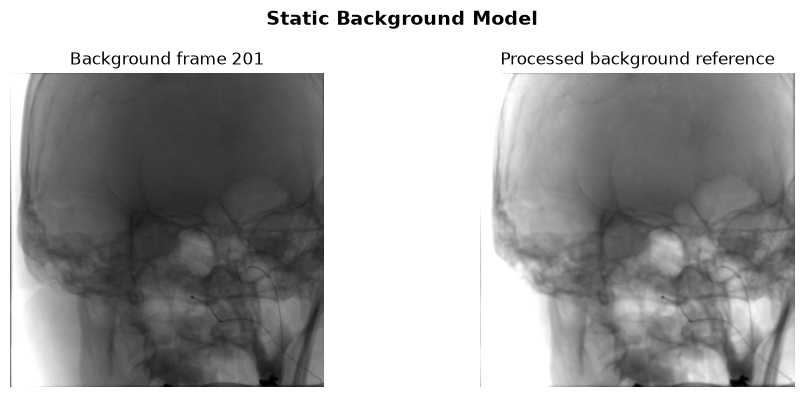

In [4]:
# Build the static background reference from frame 201.

# Load and preprocess the designated background frame once.
background_image = load_frame(
    BACKGROUND_FRAME
)

# Preprocess once; this reference is reused for all later frames.
background_reference = preprocess_frame(
    background_image
)

# Compare the raw and processed background reference.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
)

axes[0].imshow(
    background_image,
    cmap="gray",
)
axes[0].set_title(
    "Background frame 201"
)
axes[0].axis(
    "off"
)

axes[1].imshow(
    background_reference,
    cmap="gray",
)
axes[1].set_title(
    "Processed background reference"
)
axes[1].axis(
    "off"
)

fig.suptitle(
    "Static Background Model",
    fontsize=14,
    fontweight="bold",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "01_background_reference.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()


## 5. Inspect the Intermediate Pipeline on a Representative Frame

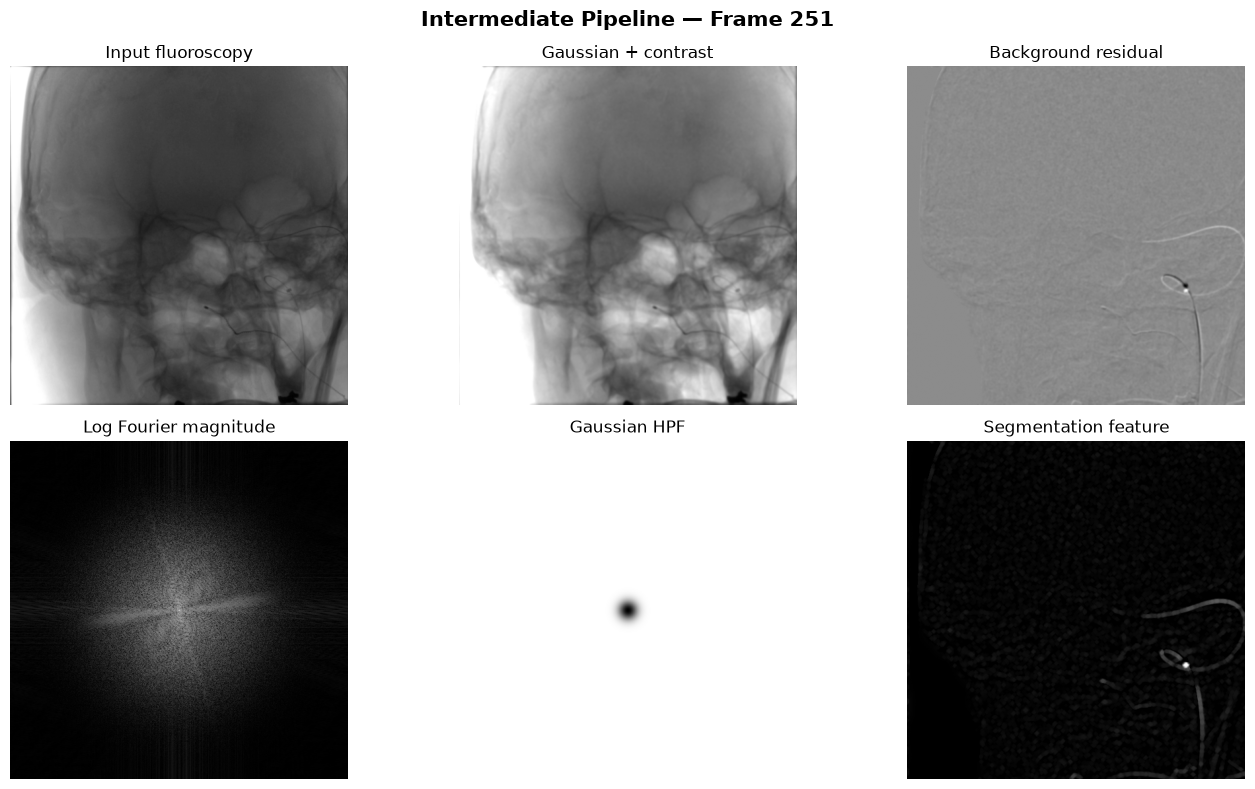

In [5]:
# Inspect the full processing chain on one representative frame.

# Use a middle-sequence frame for detailed inspection.
REPRESENTATIVE_FRAME = 251

representative_image = load_frame(
    REPRESENTATIVE_FRAME
)

# Load the annotation only for validation, not for segmentation.
representative_gt = load_ground_truth(
    REPRESENTATIVE_FRAME
)

# Compute all intermediate feature-extraction stages.
representative = build_feature_image(
    representative_image,
    background_reference,
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
)

# Pair each intermediate result with its display label.
# Display the main intermediate stages in processing order.
views = [
    (
        representative_image,
        "Input fluoroscopy",
    ),
    (
        representative[
            "processed"
        ],
        "Gaussian + contrast",
    ),
    (
        representative[
            "residual"
        ],
        "Background residual",
    ),
    (
        np.log1p(
            np.abs(
                representative[
                    "spectrum"
                ]
            )
        ),
        "Log Fourier magnitude",
    ),
    (
        representative[
            "transfer"
        ],
        "Gaussian HPF",
    ),
    (
        representative[
            "feature"
        ],
        "Segmentation feature",
    ),
]

for ax, (
    image,
    title,
) in zip(
    axes.ravel(),
    views,
):
    ax.imshow(
        image,
        cmap="gray",
    )
    ax.set_title(
        title
    )
    ax.axis(
        "off"
    )

fig.suptitle(
    f"Intermediate Pipeline — Frame {REPRESENTATIVE_FRAME}",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "02_intermediate_pipeline.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()


## 6. Generate the Three Candidate Segmentation Masks

In [6]:
# Generate three candidate masks from the same feature image.

# Strategy A: deterministic fixed threshold.
fixed_tool = segment_fixed_threshold(
    representative[
        "feature"
    ]
)

fixed_mask = finalize_mask(
    fixed_tool
)

# Strategy B: threshold estimated automatically by Otsu.
(
    otsu_tool,
    representative_otsu_threshold,
) = segment_otsu(
    representative[
        "feature"
    ]
)

otsu_mask = finalize_mask(
    otsu_tool
)

# Strategy C: two-component EM/GMM separation.
(
    gmm_tool,
    representative_gmm_means,
) = segment_gmm(
    representative[
        "feature"
    ]
)

gmm_mask = finalize_mask(
    gmm_tool
)

# Keep all candidate masks in one mapping for identical comparison.
representative_masks = {
    "Fixed Threshold": fixed_mask,
    "Otsu": otsu_mask,
    "EM / GMM": gmm_mask,
}

print(
    "Representative Otsu threshold:",
    round(
        representative_otsu_threshold,
        6,
    ),
)

print(
    "Representative GMM means:",
    np.round(
        representative_gmm_means,
        6,
    ),
)


Representative Otsu threshold: 0.099609
Representative GMM means: [0.021703 0.122893]


## 7. Compare the Candidate Strategies Qualitatively

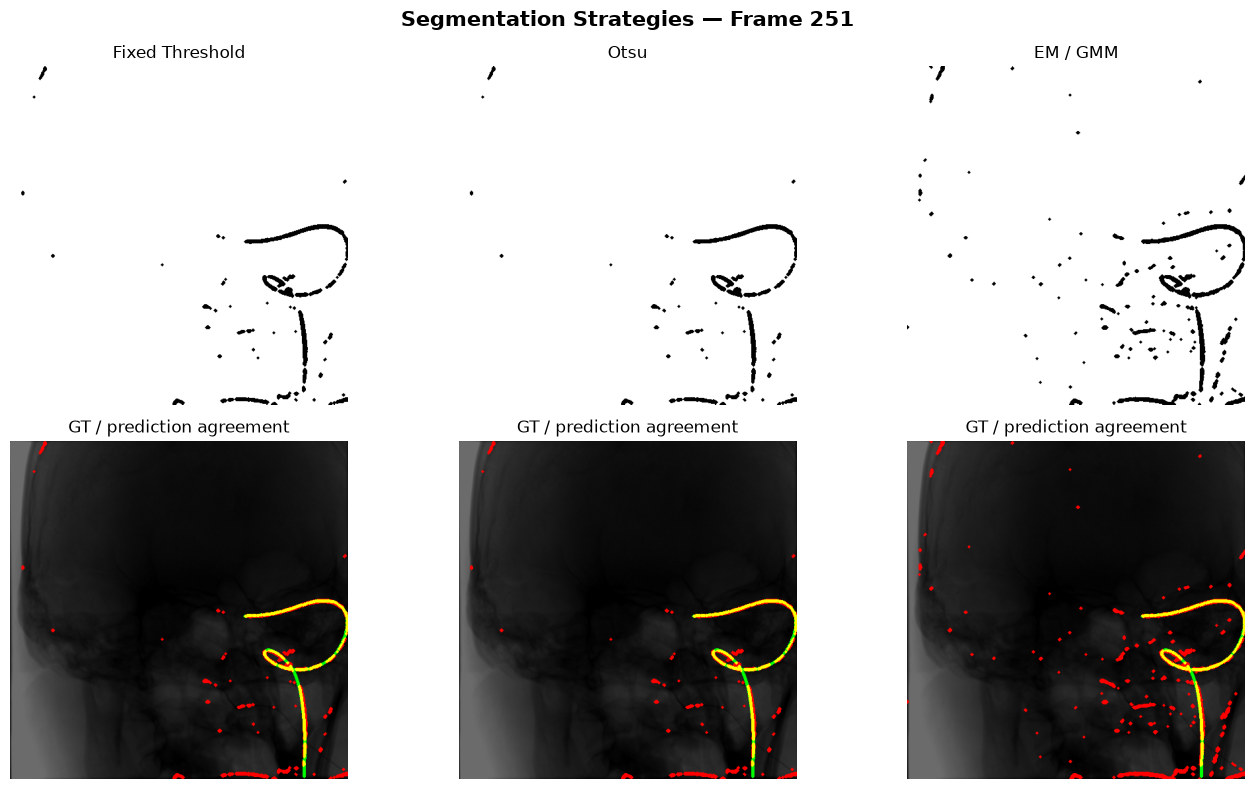

In [7]:
# Compare candidate masks visually against the manual annotation.

# First row: masks. Second row: validation overlays.
fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
)

# Use the same layout for each strategy to make visual comparison fair.
for column, (
    strategy_name,
    mask,
) in enumerate(
    representative_masks.items()
):
    axes[
        0,
        column,
    ].imshow(
        mask,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[
        0,
        column,
    ].set_title(
        strategy_name
    )

    axes[
        0,
        column,
    ].axis(
        "off"
    )

    axes[
        1,
        column,
    ].imshow(
        validation_overlay(
            representative_image,
            representative_gt,
            mask,
        )
    )

    axes[
        1,
        column,
    ].set_title(
        "GT / prediction agreement"
    )

    axes[
        1,
        column,
    ].axis(
        "off"
    )

fig.suptitle(
    f"Segmentation Strategies — Frame {REPRESENTATIVE_FRAME}",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "03_strategy_comparison_representative.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()


## 8. Evaluate All Strategies Across the Sequence

In [8]:
# Evaluate every strategy on every non-background frame.

# Store scalar metrics separately from per-frame outputs.
all_results = []
all_outputs = {}

# Apply the same processing to every evaluation frame.
# Evaluate every method on exactly the same set of frames.
for frame_number in EVALUATION_FRAMES:

    image = load_frame(
        frame_number
    )

    gt_mask = load_ground_truth(
        frame_number
    )

    pipeline = build_feature_image(
        image,
        background_reference,
    )

    fixed_prediction = finalize_mask(
        segment_fixed_threshold(
            pipeline[
                "feature"
            ]
        )
    )

    (
        otsu_tool,
        otsu_threshold,
    ) = segment_otsu(
        pipeline[
            "feature"
        ]
    )

    otsu_prediction = finalize_mask(
        otsu_tool
    )

    (
        gmm_tool,
        gmm_means,
    ) = segment_gmm(
        pipeline[
            "feature"
        ]
    )

    gmm_prediction = finalize_mask(
        gmm_tool
    )

        # Bundle predictions so one metric loop handles all strategies.
    predictions = {
        "Fixed Threshold":
            fixed_prediction,
        "Otsu":
            otsu_prediction,
        "EM / GMM":
            gmm_prediction,
    }

        # Retain intermediate data needed by later plots and validation.
    all_outputs[
        frame_number
    ] = {
        "image":
            image,
        "ground_truth":
            gt_mask,
        "feature":
            pipeline[
                "feature"
            ],
        "predictions":
            predictions,
        "otsu_threshold":
            otsu_threshold,
        "gmm_means":
            gmm_means,
    }

    for (
        strategy_name,
        prediction,
    ) in predictions.items():

        (
            sad_value,
            mse_value,
            psnr_value,
        ) = official_metrics(
            gt_mask,
            prediction,
        )

        (
            dice_value,
            iou_value,
        ) = segmentation_metrics(
            gt_mask,
            prediction,
        )

        all_results.append(
            {
                "Frame":
                    frame_number,
                "Strategy":
                    strategy_name,
                "SAD":
                    sad_value,
                "MSE":
                    mse_value,
                "PSNR":
                    psnr_value,
                "Dice":
                    dice_value,
                "IoU":
                    iou_value,
            }
        )

results_df = pd.DataFrame(
    all_results
)

display(
    results_df.round(4)
)


,Frame,Strategy,SAD,MSE,PSNR,Dice,IoU
0,211,Fixed Threshold,6.3676,1623.7398,16.0256,0.0646,0.0334
1,211,Otsu,108.3768,27636.0715,3.7160,0.0140,0.0070
2,211,EM / GMM,121.8639,31075.2943,3.2067,0.0128,0.0065
3,221,Fixed Threshold,3.0515,778.1350,19.2203,0.1995,0.1108
4,221,Otsu,107.0130,27288.3044,3.7710,0.0153,0.0077
5,221,EM / GMM,2.2188,565.8036,20.6041,0.2434,0.1386
6,231,Fixed Threshold,3.9542,1008.3261,18.0948,0.4014,0.2511
7,231,Otsu,66.2889,16903.6623,5.8510,0.0453,0.0232
8,231,EM / GMM,4.7470,1210.4874,17.3012,0.3677,0.2253
9,241,Fixed Threshold,2.6225,668.7447,19.8782,0.5513,0.3805


## 9. Aggregate Metrics and Select the Retained Strategy

In [9]:
# Aggregate frame-level metrics and retain the selected strategy.

# Compute mean and standard deviation of each metric by strategy.
summary_df = (
    results_df
    .groupby(
        "Strategy"
    )
    .agg(
        SAD_Mean=("SAD", "mean"),
        SAD_Std=("SAD", "std"),
        MSE_Mean=("MSE", "mean"),
        MSE_Std=("MSE", "std"),
        PSNR_Mean=("PSNR", "mean"),
        PSNR_Std=("PSNR", "std"),
        Dice_Mean=("Dice", "mean"),
        Dice_Std=("Dice", "std"),
        IoU_Mean=("IoU", "mean"),
        IoU_Std=("IoU", "std"),
    )
    .sort_values(
        "MSE_Mean"
    )
)

display(
    summary_df.round(4)
)

# Retain the strategy selected from the aggregated evidence.
# Use the project selection rule: lowest mean MSE.
best_strategy = (
    summary_df.index[
        0
    ]
)

print(
    "Best strategy by mean MSE:",
    best_strategy,
)


,SAD_Mean,SAD_Std,MSE_Mean,MSE_Std,PSNR_Mean,PSNR_Std,Dice_Mean,Dice_Std,IoU_Mean,IoU_Std
Strategy,,,,,,,,,,
Fixed Threshold,3.8674,1.1584,986.1944,295.3808,18.3449,1.1934,0.4749,0.2127,0.3320,0.1669
EM / GMM,17.9662,38.9842,4581.3860,9940.9804,15.7267,4.9016,0.4077,0.1809,0.2690,0.1295
Otsu,33.2963,46.9973,8490.5546,11984.3031,14.4112,7.5418,0.4301,0.3068,0.3139,0.2304


Best strategy by mean MSE: Fixed Threshold


## 10. Plot Temporal Validation Curves

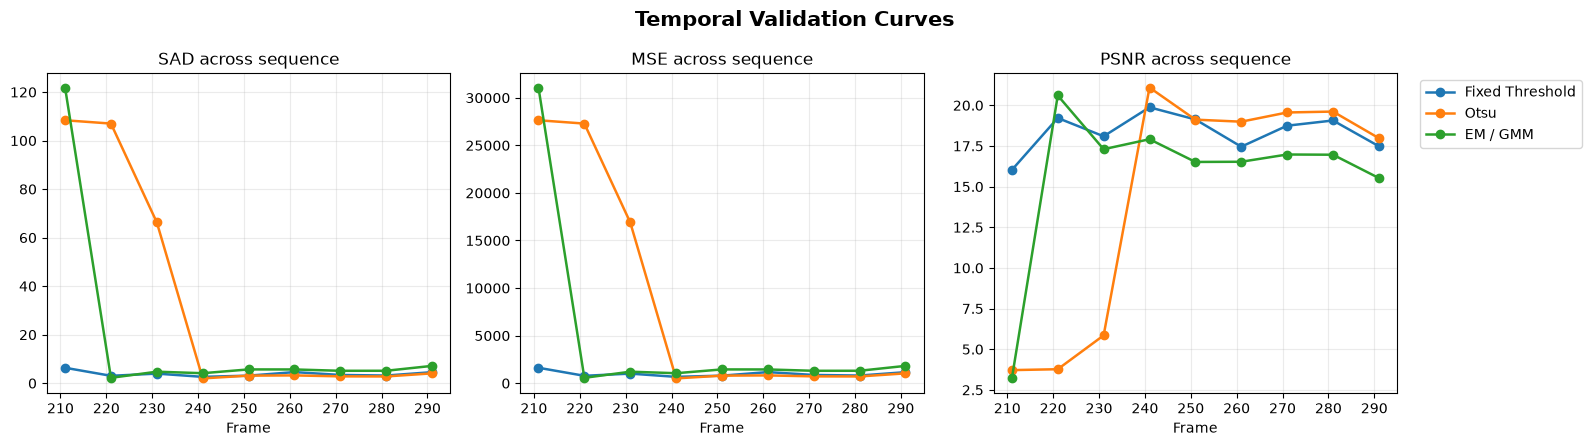

In [10]:
# Plot temporal metric curves to check stability across the sequence.

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5),
)

# Draw one curve per strategy for each temporal metric.
for ax, metric in zip(
    axes,
    [
        "SAD",
        "MSE",
        "PSNR",
    ],
):
        # Plot each strategy on the same axes for direct temporal comparison.
    for strategy_name in results_df[
        "Strategy"
    ].unique():

        subset = results_df[
            results_df[
                "Strategy"
            ]
            == strategy_name
        ]

        ax.plot(
            subset[
                "Frame"
            ],
            subset[
                metric
            ],
            marker="o",
            linewidth=1.8,
            label=strategy_name,
        )

    ax.set_xlabel(
        "Frame"
    )

    ax.set_title(
        f"{metric} across sequence"
    )

    ax.grid(
        alpha=0.25
    )

axes[
    -1
].legend(
    bbox_to_anchor=(
        1.04,
        1,
    ),
    loc="upper left",
)

fig.suptitle(
    "Temporal Validation Curves",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "04_temporal_metric_curves.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()


## 11. Summarize Strategy-Level Performance

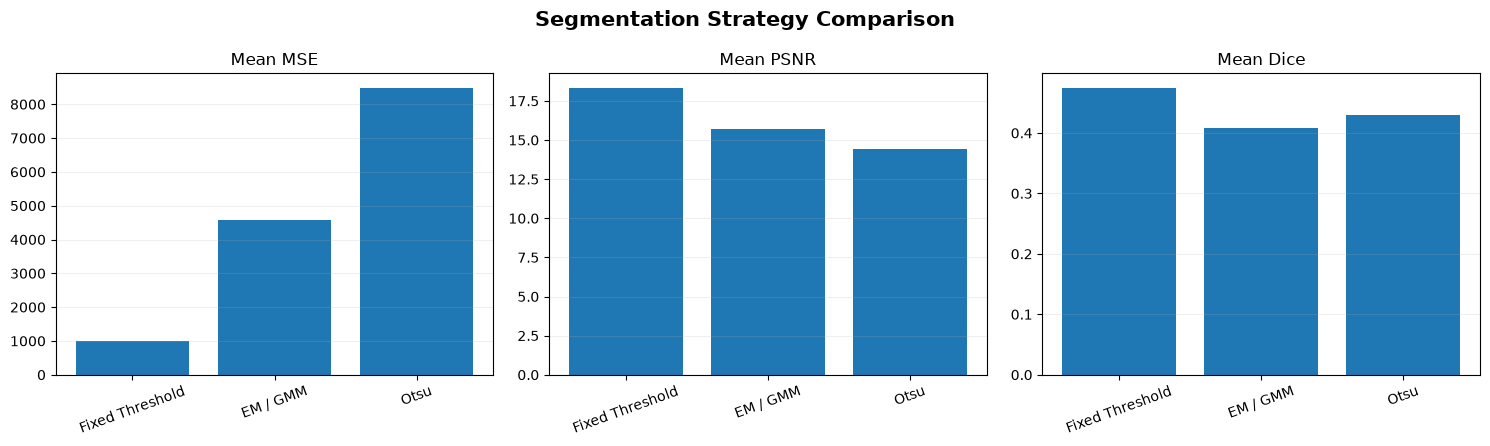

In [11]:
# Compare strategy-level average performance.

# Reset the grouped index before plotting summary bars.
plot_summary = (
    summary_df
    .reset_index()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5),
)

axes[0].bar(
    plot_summary[
        "Strategy"
    ],
    plot_summary[
        "MSE_Mean"
    ],
)
axes[0].set_title(
    "Mean MSE"
)

axes[1].bar(
    plot_summary[
        "Strategy"
    ],
    plot_summary[
        "PSNR_Mean"
    ],
)
axes[1].set_title(
    "Mean PSNR"
)

axes[2].bar(
    plot_summary[
        "Strategy"
    ],
    plot_summary[
        "Dice_Mean"
    ],
)
axes[2].set_title(
    "Mean Dice"
)

# Apply common axis formatting to all summary charts.
for ax in axes:
    ax.tick_params(
        axis="x",
        rotation=20,
    )
    ax.grid(
        axis="y",
        alpha=0.20,
    )

fig.suptitle(
    "Segmentation Strategy Comparison",
    fontsize=15,
    fontweight="bold",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "05_strategy_summary.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()


## 12. Assemble the Final Retained Pipeline

In [12]:
# Wrap the retained method into one reusable end-to-end pipeline.

# Dispatch to the requested segmentation method through one interface.
def segment_with_strategy(
    feature,
    strategy_name,
):
        # Dispatch without duplicating the complete pipeline.
    if strategy_name == "Fixed Threshold":
        return segment_fixed_threshold(
            feature
        )

    if strategy_name == "Otsu":
        tool_mask, _ = segment_otsu(
            feature
        )
        return tool_mask

    if strategy_name == "EM / GMM":
        tool_mask, _ = segment_gmm(
            feature
        )
        return tool_mask

    raise ValueError(
        f"Unknown strategy: {strategy_name}"
    )


# Execute loading, feature extraction, segmentation, cleanup, and metrics.
def final_pipeline(
    frame_number,
    strategy_name=best_strategy,
):
        # Run the retained workflow from raw frame to final binary mask.
    image = load_frame(
        frame_number
    )

    ground_truth = load_ground_truth(
        frame_number
    )

    stages = build_feature_image(
        image,
        background_reference,
    )

    tool_mask = segment_with_strategy(
        stages[
            "feature"
        ],
        strategy_name,
    )

    prediction = finalize_mask(
        tool_mask
    )

    return {
        "image":
            image,
        "feature":
            stages[
                "feature"
            ],
        "prediction":
            prediction,
        "ground_truth":
            ground_truth,
    }


print(
    "Retained segmentation strategy:",
    best_strategy,
)


Retained segmentation strategy: Fixed Threshold


## 13. Generate the Final Guidance Gallery

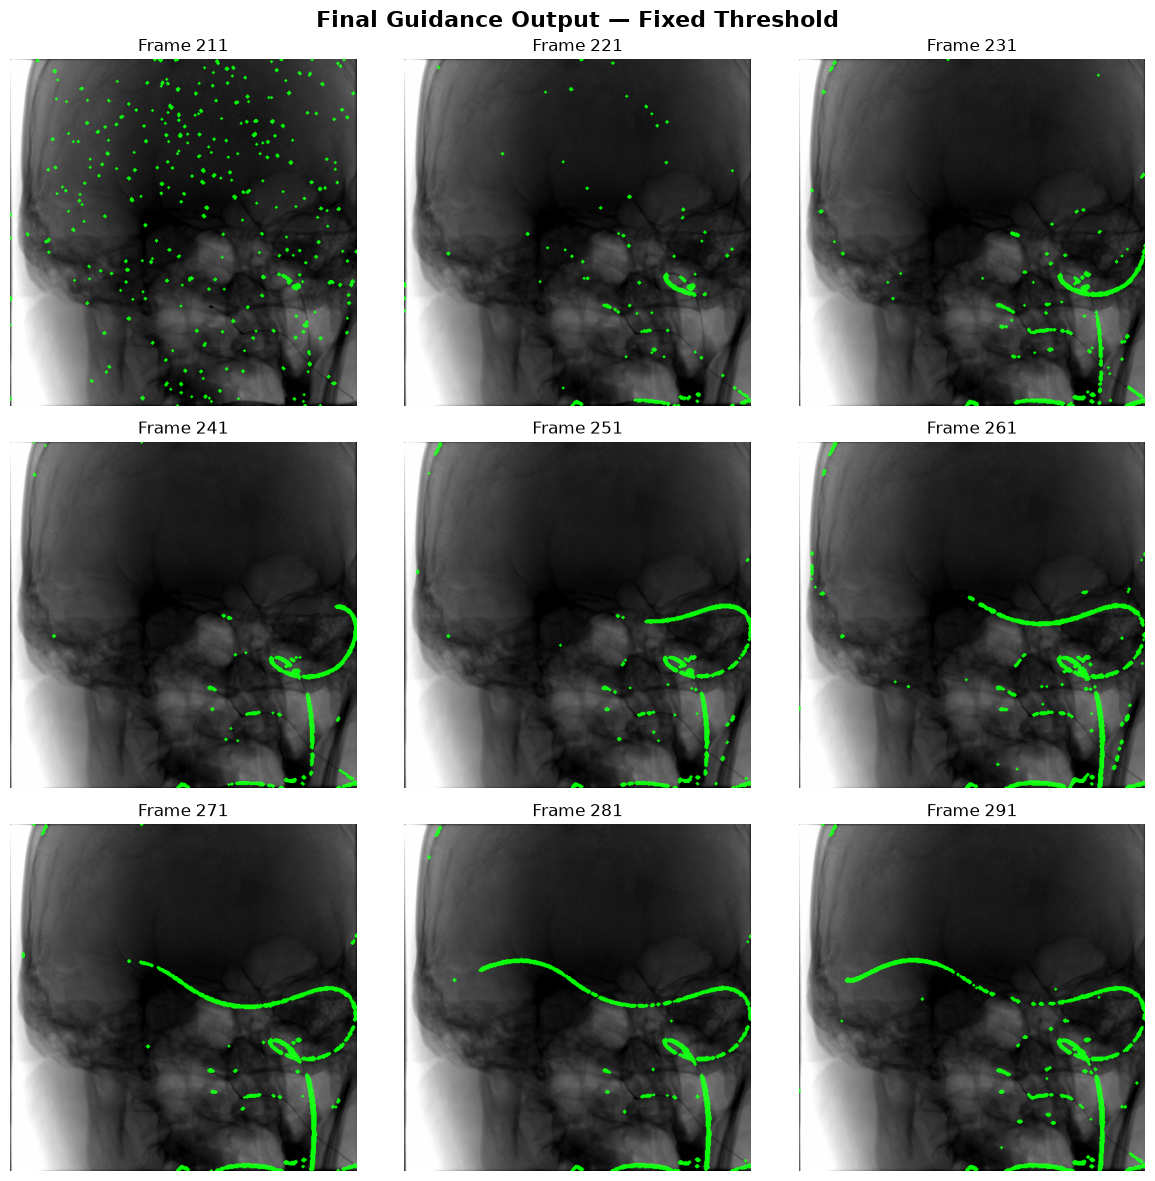

In [13]:
# Generate final guidance overlays for the evaluation sequence.

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 12),
)

# Run the retained pipeline once per evaluation frame.
for ax, frame_number in zip(
    axes.ravel(),
    EVALUATION_FRAMES,
):
    result = final_pipeline(
        frame_number,
        strategy_name=best_strategy,
    )

        # Convert the predicted tool mask into the final guidance visualization.
    overlay = guidance_overlay(
        result[
            "image"
        ],
        result[
            "prediction"
        ],
    )

    ax.imshow(
        overlay
    )

    ax.set_title(
        f"Frame {frame_number}"
    )

    ax.axis(
        "off"
    )

fig.suptitle(
    f"Final Guidance Output — {best_strategy}",
    fontsize=16,
    fontweight="bold",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "06_final_guidance_gallery.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()


## 14. Perform Final Qualitative Validation

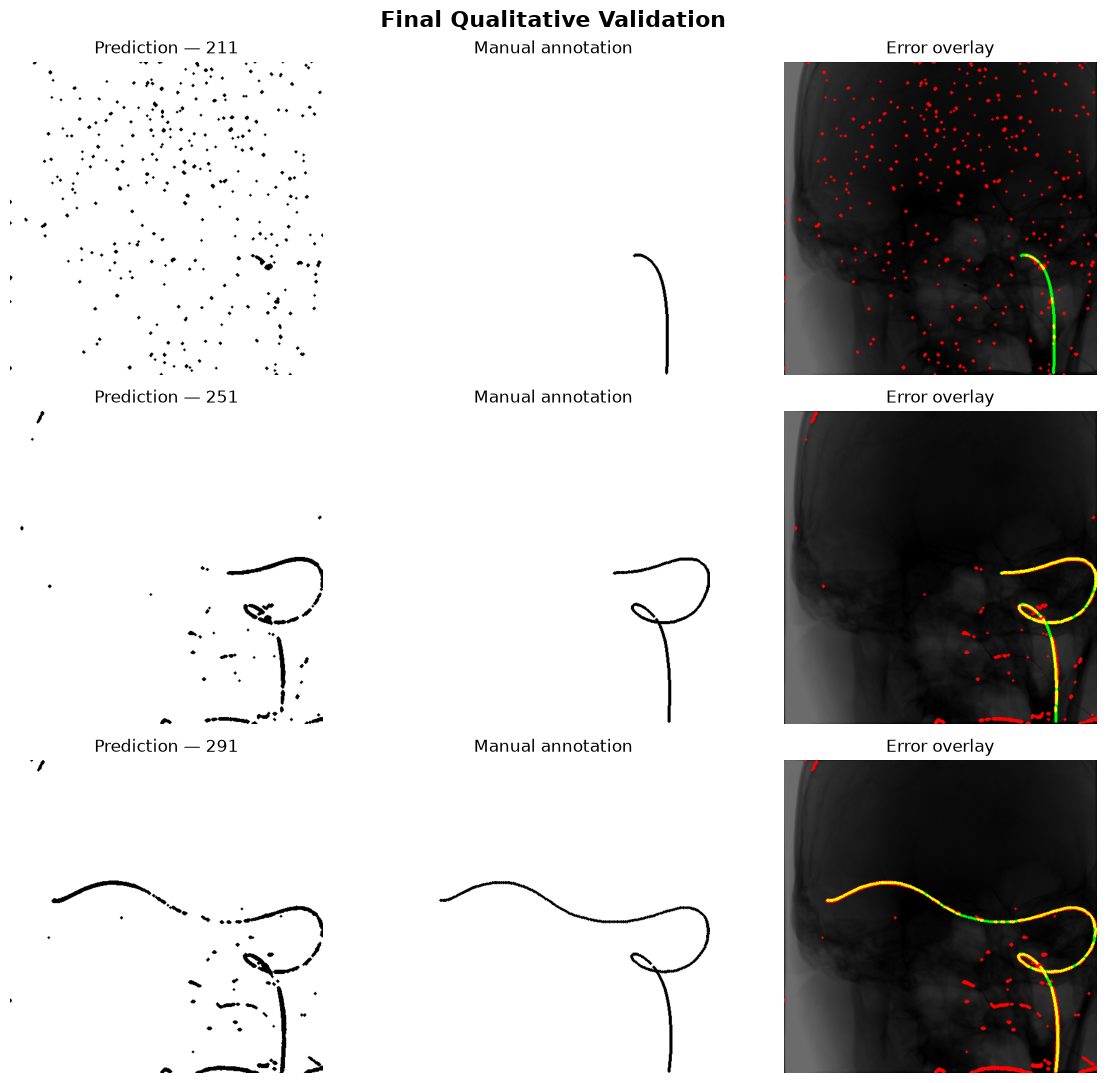

In [14]:
# Validate representative early, middle, and late frames qualitatively.

# Sample early, middle, and late frames from the sequence.
VALIDATION_FRAMES = [
    211,
    251,
    291,
]

fig, axes = plt.subplots(
    len(
        VALIDATION_FRAMES
    ),
    3,
    figsize=(12, 11),
)

# Compare prediction, annotation, and error overlay side by side.
# Validate three sequence positions to catch time-dependent failures.
for row, frame_number in enumerate(
    VALIDATION_FRAMES
):
    result = final_pipeline(
        frame_number,
        strategy_name=best_strategy,
    )

    axes[
        row,
        0,
    ].imshow(
        result[
            "prediction"
        ],
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[
        row,
        0,
    ].set_title(
        f"Prediction — {frame_number}"
    )

    axes[
        row,
        1,
    ].imshow(
        result[
            "ground_truth"
        ],
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[
        row,
        1,
    ].set_title(
        "Manual annotation"
    )

    axes[
        row,
        2,
    ].imshow(
        validation_overlay(
            result[
                "image"
            ],
            result[
                "ground_truth"
            ],
            result[
                "prediction"
            ],
        )
    )

    axes[
        row,
        2,
    ].set_title(
        "Error overlay"
    )

    for column in range(3):
        axes[
            row,
            column,
        ].axis(
            "off"
        )

fig.suptitle(
    "Final Qualitative Validation",
    fontsize=16,
    fontweight="bold",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "07_final_validation.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()


## 15. Export Results and Verify Deliverables

In [15]:
# Export metrics and verify the generated deliverables.

results_csv = (
    OUTPUT_DIR
    / "background_subtraction_metrics.csv"
)

summary_csv = (
    OUTPUT_DIR
    / "background_subtraction_summary.csv"
)

# Save frame-level metrics without the DataFrame index.
results_df.to_csv(
    results_csv,
    index=False,
)

# Save the aggregated strategy summary.
summary_df.to_csv(
    summary_csv,
)

print(
    "Saved:",
    results_csv
)

print(
    "Saved:",
    summary_csv
)

print()
print(
    "Generated figures:"
)

# List regenerated figures as a final deliverable check.
# Confirm which figures were regenerated during this run.
for figure_path in sorted(
    FIGURE_DIR.glob(
        "*.png"
    )
):
    print(
        " -",
        figure_path.name,
    )


Saved: ../outputs/background_subtraction_metrics.csv
Saved: ../outputs/background_subtraction_summary.csv

Generated figures:
 - 01_background_reference.png
 - 02_intermediate_pipeline.png
 - 03_strategy_comparison_representative.png
 - 04_temporal_metric_curves.png
 - 05_strategy_summary.png
 - 06_final_guidance_gallery.png
 - 07_final_validation.png
